## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** BAI Yongqi

**Date:** 2026/10/02

1. Regression predicts a numeric target like price or sales, while classification predicts a categorical target like vehicle class or mine type. In kNN, regression averages the outcomes of the k nearest neighbors, and classification predicts the most common class among them.

2. A confusion matrix is a table of counts with actual classes as rows and predicted classes as columns. Diagonal cells are correct predictions and off-diagonal cells are misclassifications. With two classes, the four cells are the true/false positives and negatives. Unlike accuracy alone, the matrix shows which classes are misclassified and as what, and whether the errors are the costly kind, such as false negatives. In the lecture's car example, the model never predicts "station wagon" at all. This shows up in the confusion matrix but not in accuracy.

3. SSE adds up the squared residuals on the validation set: $SSE(k)=\sum_i \left(y_i-\hat{y}(x_i,k)\right)^2$, where the residual $e_i=y_i-\hat{y}_i$ is the error of one prediction, positive or negative. It measures how large a regression model's errors are in total, and a lower validation SSE means smaller errors on that set. Squaring drops the sign and weights big misses heavily. SSE is mainly used to compare models on the same data, for example to choose k.

4. Overfitting means fitting the noise in the training data, so training error is low but predictions on new data are poor. In kNN this happens with a very small k, where predictions jump around. Underfitting means the model is too simple to capture real differences, so it does poorly on both the training data and new data. With a very large k, kNN gives nearly the same prediction for every observation, which is why the k = 470 surface in the slides is almost flat.

5. k is a hyperparameter. Training error always favors a very small k, so choosing k by training error leads to overfitting. A separate validation set shows how well the model predicts data it was not fit on. Because of this, the k with the lowest validation SSE or highest accuracy is the one expected to predict best on new data. However, the result depends on how the data is split. The chosen k's score is also optimistic because the same data was used to pick it, so the final evaluation needs a separate test set. 

6. A label, the most common class among the k neighbors, is simple to act on and easy to score with a confusion matrix. But it hides how sure the model is, since a 2-1 vote and a unanimous vote give the same answer. Class proportions, each class's neighbor count divided by k, show that uncertainty. They also let the user choose a cutoff that fits the cost of each mistake. The downside is that someone still has to pick the cutoff, and with a small k the proportions are coarse. With k = 3, they can only be 0, 1/3, 2/3 or 1.

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
soil
0.0    59
0.2    51
0.4    56
0.6    57
0.8    58
1.0    57
Name: count, dtype: int64
height
0.000000    22
0.090909    27
0.181818    30
0.272727    28
0.363636    29
0.454545    29
0.545455    30
0.636364    30
0.727273    29
0.818182    29
0.909091    28
1.000000    27
Name: count, dtype: int64
           count   mean    std    min    25%    50% 

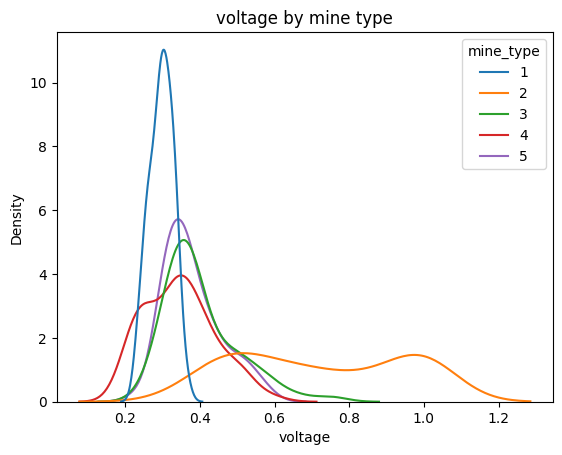

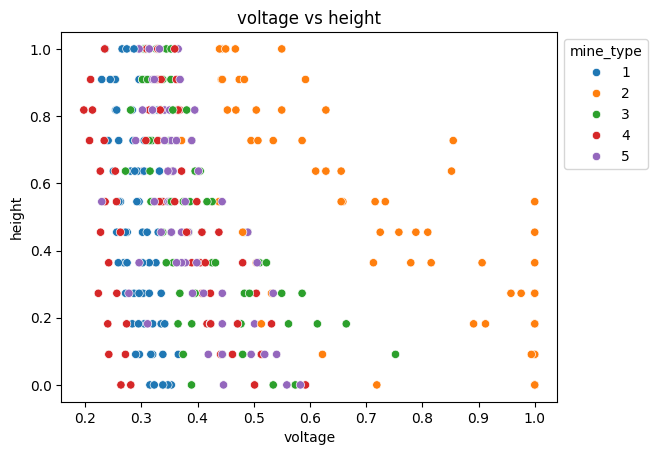

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('./data/land_mines.csv')
print(df.shape)
print(df.isnull().sum())
print(df.describe())

# the target
print(df['mine_type'].value_counts().sort_index())

# the features
print(df['soil'].value_counts().sort_index())
print(df['height'].value_counts().sort_index())
print(df.groupby('mine_type')['voltage'].describe().round(3))
print('readings stuck at the top of the voltage scale:', (df['voltage'] > 0.9999).sum())

# every mine type was measured on every soil, roughly the same number of times
print(pd.crosstab(df['mine_type'], df['soil']))

sns.kdeplot(data=df, x='voltage', hue='mine_type', common_norm=False, palette='tab10')
plt.title('voltage by mine type')
plt.show()

this_plot = sns.scatterplot(data=df, x='voltage', y='height', hue='mine_type', palette='tab10')
sns.move_legend(this_plot, "upper left", bbox_to_anchor=(1, 1))
plt.title('voltage vs height')
plt.show()

The dataset has 338 readings and no missing values. The target is balanced, with 65 to 71 readings per mine type. According to the UCI documentation, type 1 is no mine, type 2 is anti-tank, and types 3 to 5 are anti-personnel mines, of which type 4 is booby-trapped.

 - Voltage is the only feature that separates the types. Type 1 stays within a narrow range of 0.23 to 0.37. Type 2 is much higher, with a mean of 0.72, and 18 of its readings reach the top of the scale. Types 3 to 5 overlap almost completely, running from about 0.2 to 0.75, and cover type 1's range as well.

 - Height alone says nothing about the type, since every type was measured at every height. But voltage drops as the sensor gets higher, so at the top heights types 1, 3, 4 and 5 look alike.

 - Soil is spread evenly across the types. Every type and soil combination has 10 to 12 readings except one with 7, which means soil carries no information by itself. It is a categorical variable stored as values from 0 to 1 in steps of 0.2, so kNN treats it as a distance whether or not that means anything. 

In [2]:
y = df['mine_type']
X_raw = df[['voltage', 'height', 'soil']]


X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y, test_size=0.5, stratify=y, random_state=100
)


scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)
n_valid = len(y_valid)
print(y_train.value_counts().sort_index())
print(y_valid.value_counts().sort_index())

mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


The sample is split 50/50, stratified on mine type, so each half gets 32 to 36 of every type and no type ends up in only one half.

k_star: 3 | validation accuracy: 0.467
validation accuracy, k = 1 to 5: [0.391 0.42  0.467 0.379 0.402]
training accuracy, k = 1 to 5: [1.    0.728 0.692 0.639 0.598]


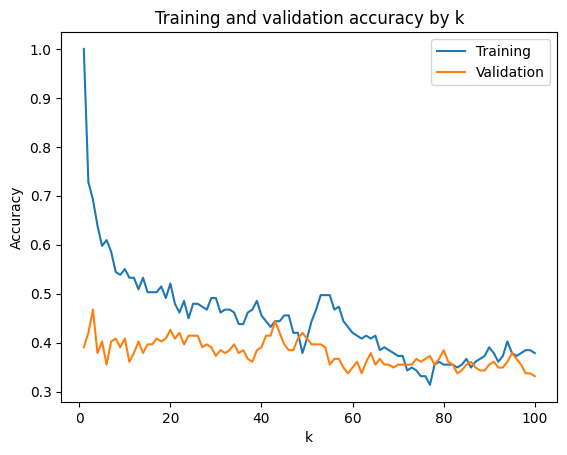

In [3]:
# fit a model for each k on the training half and compare accuracy on the validation half
ks = np.arange(1, 101)
valid_acc = []
train_acc = []
for k in ks:
    candidate = KNeighborsClassifier(n_neighbors=int(k))
    candidate.fit(X_train, y_train)
    valid_acc.append(np.mean(candidate.predict(X_valid) == y_valid))
    train_acc.append(np.mean(candidate.predict(X_train) == y_train))

k_star = int(ks[np.argmax(valid_acc)])
print('k_star:', k_star, '| validation accuracy:', round(max(valid_acc), 3))
print('validation accuracy, k = 1 to 5:', np.round(valid_acc[:5], 3))
print('training accuracy, k = 1 to 5:', np.round(train_acc[:5], 3))

plt.plot(ks, train_acc, label='Training')
plt.plot(ks, valid_acc, label='Validation')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and validation accuracy by k')
plt.show()

k is a hyperparameter, so it is chosen by validation accuracy rather than training accuracy. Training accuracy is 100% at k = 1, since each training point is its own nearest neighbor, so it would always pick the smallest k. Following the slides, I fit every k from 1 to 100 on the training half, scored it on the validation half, and kept the k with the highest validation accuracy. That is k = 3, at 46.7%.

The validation curve is noisy, and k = 3 is a lone spike, with k = 2 at 42.0% and k = 4 at 37.9%. As the slides warn, another split could give a different best k, and because the same data picked k and scored it, 46.7% is probably optimistic.

In [4]:
model = KNeighborsClassifier(n_neighbors=k_star)
fitted_model = model.fit(X_train, y_train)
y_hat = fitted_model.predict(X_valid)

# rows are actual classes, columns are predictions, as in the slides
tab = pd.crosstab(y_valid, y_hat, rownames=['actual'], colnames=['predicted'])
print(tab)
print('accuracy:', np.sum(y_hat == y_valid)/n_valid)

# share of each actual type predicted correctly
print((np.diag(tab)/tab.sum(axis=1)).round(3))

# coarser questions: the three anti-personnel types pooled, and plain mine vs no mine
y_valid_3 = y_valid.replace([4, 5], 3)
y_hat_3 = pd.Series(y_hat).replace([4, 5], 3)
print('types 3-5 pooled:', np.mean(y_valid_3.values == y_hat_3.values).round(3))
print('mine vs no mine:', np.mean((y_valid.values != 1) == (y_hat != 1)).round(3))

# does it matter how high the sensor was?
results = df.loc[y_valid.index].copy()
results['y_hat'] = y_hat
results['correct'] = results['y_hat'] == results['mine_type']
results['height_band'] = pd.cut(results['height'], [-0.01, 1/3, 2/3, 1.01], labels=['low', 'mid', 'high'])
print(results.groupby('height_band', observed=True)['correct'].mean().round(3))

# real mines (types 2-5) that got called type 1
mines = results.loc[results['mine_type'] != 1].copy()
mines['called_1'] = mines['y_hat'] == 1
print('mines called type 1:', mines['called_1'].sum(), 'of', len(mines))
print(mines.groupby('height_band', observed=True)['called_1'].mean().round(3))

predicted   1   2   3  4  5
actual                     
1          26   0   4  2  4
2           0  30   2  2  1
3          12   3  10  1  7
4           9   4  10  8  2
5          10   1  14  2  5
accuracy: 0.46745562130177515
actual
1    0.722
2    0.857
3    0.303
4    0.242
5    0.156
dtype: float64
types 3-5 pooled: 0.68
mine vs no mine: 0.757
height_band
low     0.519
mid     0.548
high    0.327
Name: correct, dtype: float64
mines called type 1: 31 of 133
height_band
low     0.098
mid     0.188
high    0.409
Name: called_1, dtype: float64


The model gets 79 of 169 validation readings right, an accuracy of 46.7%. Guessing among five balanced types would get about 20%, so it has learned something, but it still gets more than half wrong.

It does best on type 2, the anti-tank mine, with 30 of 35 right, because its voltage is far above everything else. It also gets 26 of 36 no-mine readings right and never confuses types 1 and 2.

It does poorly on the anti-personnel types, getting only 30%, 24% and 16% of types 3, 4 and 5 right. Of their 75 errors, 36 go to another anti-personnel type, 31 go to type 1 and 8 go to type 2, which fits how their voltages overlap in the EDA. Pooling the three types into one group raises accuracy to 68%. The 31 mines called type 1 are false negatives, the most costly kind of error here. About one anti-personnel mine in three gets declared empty ground.

Sensor height also matters. Accuracy is 52% to 55% in the low and middle bands but drops to 33% in the high band, where 41% of mines are called type 1 compared with 10% in the low band. Higher up, mine readings fade into the no-mine baseline.

In [5]:
props = fitted_model.predict_proba(X_valid)   # one column per type, 1 to 5
split_vote = props.max(axis=1) < 0.5          # 3 neighbors, 3 different types
print('three-way splits:', split_vote.sum(), 'of', n_valid)
print('how sklearn settled them:', pd.Series(y_hat[split_vote]).value_counts().sort_index().to_dict())
print('missed mines that came from a three-way split:', np.sum(split_vote & (y_hat == 1) & (y_valid.values != 1)))

# stricter rule: only call a spot clear if all 3 neighbors are type 1
clear = props[:, 0] == 1
print('mines called clear:', np.sum(clear & (y_valid.values != 1)), 'of', np.sum(y_valid.values != 1))
print('empty ground called clear:', np.sum(clear & (y_valid.values == 1)), 'of', np.sum(y_valid.values == 1))

three-way splits: 73 of 169
how sklearn settled them: {1: 42, 2: 13, 3: 18}
missed mines that came from a three-way split: 25
mines called clear: 0 of 133
empty ground called clear: 1 of 36


Use the model to decide where to look first, never where it is safe to walk.

1. Never use a "no mine" prediction to clear ground. The model calls 31 of 98 anti-personnel mines "no mine". A false alarm only costs time, but a missed mine can cost a life, so every spot still gets checked by hand and the model only sets the order.
2. Look at the class proportions, not just the label. In 73 of 169 validation cases, the three neighbors were three different types. Scikit-learn breaks these ties by picking the lowest type number, so a tie with a type 1 neighbor always becomes "no mine". Twenty-five of the 31 missed mines come from such ties, so the model was not confident those spots were empty. If a spot is called clear only when all three neighbors are type 1, no mine gets through, but only 1 of the 36 empty spots gets cleared either. The model cannot certify ground as safe.
3. Don't rely on it to tell anti-personnel types apart. It gets only 16% to 30% of types 3 to 5 right, so any 3, 4 or 5 prediction should be handled as a possible booby-trapped mine, the worst case.
4. Take readings close to the ground. The share of mines called "no mine" rises from 10% in the low height band to 41% in the high band, so an empty-looking reading taken high up means little.
5. Test it on field data before using it. This data has about the same number of readings for every mine type on every soil. In the field, most readings will be empty ground and the mix of mines will differ, so the error rates will change.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** ff7fae2bb3b6b4c2dff7614658b04cf042b637e5
- **AI tool and model used:** Claude Opus

### *Prompts used

1. examine carefully

### *AI-proposed changes


Q1

1. No factual errors found in Q1. The two references to the slides were
   checked against the kNN lecture (the car example with k = 9 never
   predicts "station wagon"; the k = 470 surface is nearly flat).
   Suggestion: in 1.2, say the car example used k = 9, since that result
   depends on k.

2. 1.3: add that SSE grows with the number of observations and is in
   squared units of the target, so it can only compare models scored on
   the same validation set. To compare sets of different sizes, use MSE
   or RMSE.

3. 1.4: tie the definition to evidence from Q2. At k = 1, training
   accuracy is 100% while validation accuracy is 39.1%. That gap is what
   overfitting looks like.

4. 1.6: kNN class proportions are not calibrated probabilities. With
   k = 3, a 2/3 vote is not a 67% chance, so the proportions are better
   used to rank cases than read as probabilities.

Q2

5. Q2.3 says 46.7% is "probably optimistic". Make that a number by
   rerunning the same pipeline over many random splits. Over 200 splits,
   accuracy at k = 3 averages 40.9% (sd 3.0); only 4% of splits reach
   46.7%. Over 50 splits, the validation-best k ranges from 1 to 19 and
   is 3 in only 8% of them.

6. Q2.1 notes soil is categorical and uninformative on its own, but all
   three features enter the distance with equal weight. Test feature
   subsets. Choosing k by 5-fold CV inside the training half and scoring
   once on the held-out half, averaged over 30 splits: voltage only
   44.4%, voltage + height 45.3%, voltage + soil 49.3%, all three 41.8%,
   one-hot soil with voltage + height 37.7%. Soil helps only in
   combination with voltage, and adding height on top hurts. Caveat:
   choosing features by held-out accuracy carries the same optimism as
   choosing k that way.

7. Q2.5 point 2 compares two extremes: sklearn's default (31 of 133 mines
   called clear, 26 of 36 empty spots cleared) and a unanimous rule (0
   and 1). Add the middle rule: call a spot clear only if at least 2 of
   the 3 neighbors are type 1. That gives 6 of 133 mines called clear and
   9 of 36 empty spots cleared, which shows the trade-off rather than two
   end points.

8. Q2.3 chooses k and reports accuracy on the same half. Choosing k by
   5-fold CV inside the training half keeps the held-out half untouched;
   for random_state = 100 it picks k = 2, with 42.0% held-out accuracy.
   Note that the assignment asks for k to be chosen on the test set, and
   cross-validation comes later in the course.

9. Two EDA claims in Q2.1 have no output behind them. Add per-type
   counts showing all 18 top-of-scale voltage readings are type 2, and
   per-type correlations between voltage and height (negative for every
   type, -0.41 to -0.78), which support "voltage drops as the sensor gets
   higher".

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | Accurate, but adding k = 9 does not change the point of 1.2, which is that accuracy can hide a class the model never predicts. |
| 2 | Reject | 1.3 already says SSE is used to compare models on the same data. MSE and RMSE go beyond what the question asks. |
| 3 | Accept | Ties the definition to my own results. Verified from the Q2.3 output: at k = 1, training accuracy is 1.000 and validation accuracy is 0.391. Added one sentence to 1.4. |
| 4 | Accept | Tested on my k = 3 model: when 2 of 3 neighbors agree (n = 70), the prediction is right 40.0% of the time, not 67%. Unanimous votes (n = 26) are right 88.5% of the time and three-way ties (n = 73) 38.4%. The claim holds, even more strongly than stated. Added one sentence to 1.6. |
| 5 | Accept | Turns "probably optimistic" into a number. Reran my own pipeline over 200 seeds: k = 3 averages 0.409 (sd 0.030), and only 4.0% of splits reach 0.467. Over 50 seeds the best k ranges from 1 to 19 and equals 3 in 8% of them. Revised the Q2.3 text. |
| 6 | Reject | Changing the features would change every number in Q2.4 and Q2.5, and the gain comes with the same selection optimism that change 5 measures. Listed as a remaining concern instead. |
| 7 | Accept | Fills the gap between my two rules. Verified with props[:, 0] > 0.5: 6 of 133 mines called clear and 9 of 36 empty spots cleared, compared with 31 and 26 under the default rule. Added to Q2.5 point 2. |
| 8 | Reject | The assignment asks for k to be chosen on the test set, and cross-validation has not been covered yet. Q1.5 and Q2.3 already say this makes the score optimistic. |
| 9 | Reject | Both claims already have output behind them. The per-type voltage table shows only type 2 goes above 0.752, so all 18 top readings must be type 2, and the voltage vs height scatter plot shows the drop. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Q1 (Phase 2: answers 4 and 6 revised, changes 3 and 4)

1. Regression predicts a numeric target like price or sales, while classification predicts a categorical target like vehicle class or mine type. In kNN, regression averages the outcomes of the k nearest neighbors, and classification predicts the most common class among them.

2. A confusion matrix is a table of counts with actual classes as rows and predicted classes as columns. Diagonal cells are correct predictions and off-diagonal cells are misclassifications. With two classes, the four cells are the true/false positives and negatives. Unlike accuracy alone, the matrix shows which classes are misclassified and as what, and whether the errors are the costly kind, such as false negatives. In the lecture's car example, the model never predicts "station wagon" at all. This shows up in the confusion matrix but not in accuracy.

3. SSE adds up the squared residuals on the validation set: $SSE(k)=\sum_i \left(y_i-\hat{y}(x_i,k)\right)^2$, where the residual $e_i=y_i-\hat{y}_i$ is the error of one prediction, positive or negative. It measures how large a regression model's errors are in total, and a lower validation SSE means smaller errors on that set. Squaring drops the sign and weights big misses heavily. SSE is mainly used to compare models on the same data, for example to choose k.

4. Overfitting means fitting the noise in the training data, so training error is low but predictions on new data are poor. In kNN this happens with a very small k, where predictions jump around. Underfitting means the model is too simple to capture real differences, so it does poorly on both the training data and new data. With a very large k, kNN gives nearly the same prediction for every observation, which is why the k = 470 surface in the slides is almost flat. In Q2, k = 1 gives 100% training accuracy but only 39.1% validation accuracy, and that gap is what overfitting looks like.

5. k is a hyperparameter. Training error always favors a very small k, so choosing k by training error leads to overfitting. A separate validation set shows how well the model predicts data it was not fit on. Because of this, the k with the lowest validation SSE or highest accuracy is the one expected to predict best on new data. However, the result depends on how the data is split. The chosen k's score is also optimistic because the same data was used to pick it, so the final evaluation needs a separate test set.

6. A label, the most common class among the k neighbors, is simple to act on and easy to score with a confusion matrix. But it hides how sure the model is, since a 2-1 vote and a unanimous vote give the same answer. Class proportions, each class's neighbor count divided by k, show that uncertainty. They also let the user choose a cutoff that fits the cost of each mistake. The downside is that someone still has to pick the cutoff, and with a small k the proportions are coarse. With k = 3, they can only be 0, 1/3, 2/3 or 1. They are also not calibrated probabilities. In Q2, when 2 of the 3 neighbors agree, the prediction is right only 40.0% of the time, not 67%, while unanimous votes are right 88.5% of the time.


(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
soil
0.0    59
0.2    51
0.4    56
0.6    57
0.8    58
1.0    57
Name: count, dtype: int64
height
0.000000    22
0.090909    27
0.181818    30
0.272727    28
0.363636    29
0.454545    29
0.545455    30
0.636364    30
0.727273    29
0.818182    29
0.909091    28
1.000000    27
Name: count, dtype: int64
           count   mean    std    min    25%    50% 

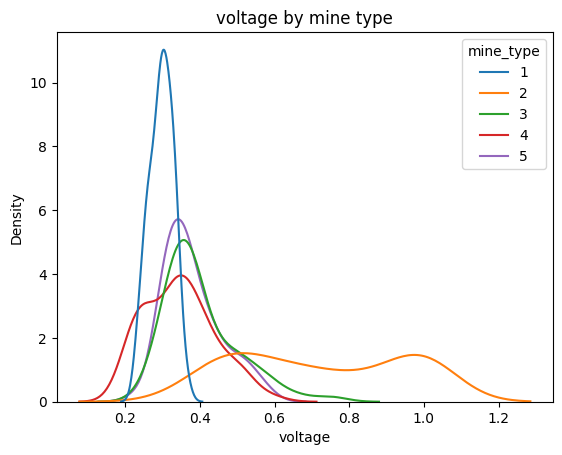

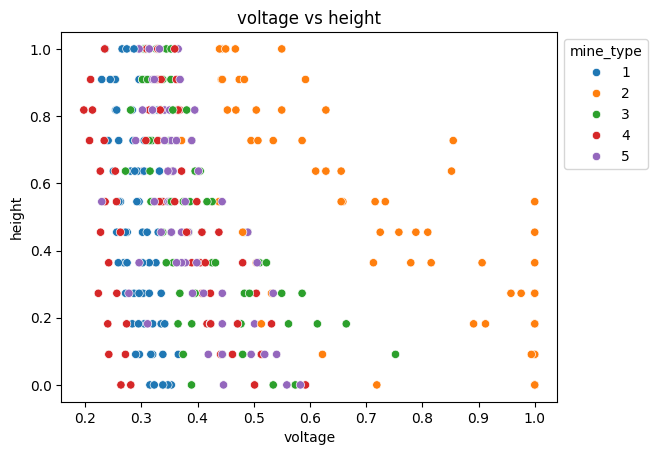

mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
k_star: 3 | validation accuracy: 0.467
validation accuracy, k = 1 to 5: [0.391 0.42  0.467 0.379 0.402]
training accuracy, k = 1 to 5: [1.    0.728 0.692 0.639 0.598]


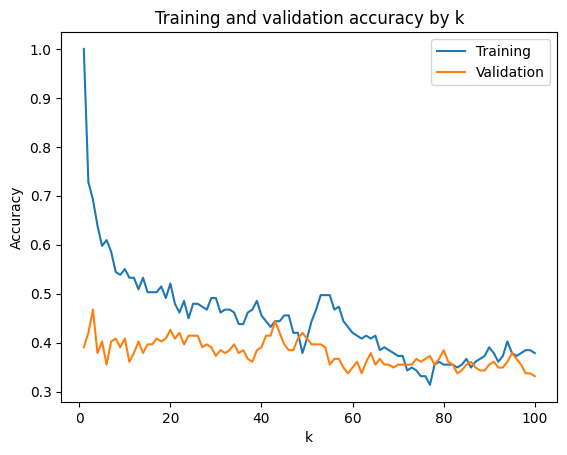

k = 3 over 200 splits: mean 0.409 | sd 0.03 | share at or above 79/169: 0.04
validation-best k over 50 splits: from 1 to 19 | share equal to 3: 0.08
predicted   1   2   3  4  5
actual                     
1          26   0   4  2  4
2           0  30   2  2  1
3          12   3  10  1  7
4           9   4  10  8  2
5          10   1  14  2  5
accuracy: 0.46745562130177515
actual
1    0.722
2    0.857
3    0.303
4    0.242
5    0.156
dtype: float64
types 3-5 pooled: 0.68
mine vs no mine: 0.757
height_band
low     0.519
mid     0.548
high    0.327
Name: correct, dtype: float64
mines called type 1: 31 of 133
height_band
low     0.098
mid     0.188
high    0.409
Name: called_1, dtype: float64
three-way splits: 73 of 169
how sklearn settled them: {1: 42, 2: 13, 3: 18}
missed mines that came from a three-way split: 25
mines called clear: 0 of 133
empty ground called clear: 1 of 36
3 of 3 agree | n = 26 | correct: 0.885
2 of 3 agree | n = 70 | correct: 0.4
three-way tie | n = 73 | correct: 0.

In [7]:
# Phase 2 solution, Q2. Phase 1 code unchanged; added change 5 (split check)
# after choosing k, and changes 4 and 7 (vote shares, middle rule) at the end.

# ---------- Q2.1 load data and EDA ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('./data/land_mines.csv')
print(df.shape)
print(df.isnull().sum())
print(df.describe())

# the target
print(df['mine_type'].value_counts().sort_index())

# the features
print(df['soil'].value_counts().sort_index())
print(df['height'].value_counts().sort_index())
print(df.groupby('mine_type')['voltage'].describe().round(3))
print('readings stuck at the top of the voltage scale:', (df['voltage'] > 0.9999).sum())

# every mine type was measured on every soil, roughly the same number of times
print(pd.crosstab(df['mine_type'], df['soil']))

sns.kdeplot(data=df, x='voltage', hue='mine_type', common_norm=False, palette='tab10')
plt.title('voltage by mine type')
plt.show()

this_plot = sns.scatterplot(data=df, x='voltage', y='height', hue='mine_type', palette='tab10')
sns.move_legend(this_plot, "upper left", bbox_to_anchor=(1, 1))
plt.title('voltage vs height')
plt.show()

# ---------- Q2.2 50/50 split ----------
y = df['mine_type']
X_raw = df[['voltage', 'height', 'soil']]


X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X_raw, y, test_size=0.5, stratify=y, random_state=100
)


scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)
n_valid = len(y_valid)
print(y_train.value_counts().sort_index())
print(y_valid.value_counts().sort_index())

# ---------- Q2.3 build kNN and choose k ----------
# fit a model for each k on the training half and compare accuracy on the validation half
ks = np.arange(1, 101)
valid_acc = []
train_acc = []
for k in ks:
    candidate = KNeighborsClassifier(n_neighbors=int(k))
    candidate.fit(X_train, y_train)
    valid_acc.append(np.mean(candidate.predict(X_valid) == y_valid))
    train_acc.append(np.mean(candidate.predict(X_train) == y_train))

k_star = int(ks[np.argmax(valid_acc)])
print('k_star:', k_star, '| validation accuracy:', round(max(valid_acc), 3))
print('validation accuracy, k = 1 to 5:', np.round(valid_acc[:5], 3))
print('training accuracy, k = 1 to 5:', np.round(train_acc[:5], 3))

plt.plot(ks, train_acc, label='Training')
plt.plot(ks, valid_acc, label='Validation')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and validation accuracy by k')
plt.show()

# Phase 2 change 5: how much does the result depend on the split?
acc_k3 = []
for seed in range(200):
    Xtr_r, Xva_r, ytr_s, yva_s = train_test_split(X_raw, y, test_size=0.5, stratify=y, random_state=seed)
    sc = MinMaxScaler()
    Xtr_s = sc.fit_transform(Xtr_r)
    Xva_s = sc.transform(Xva_r)
    m3 = KNeighborsClassifier(n_neighbors=3).fit(Xtr_s, ytr_s)
    acc_k3.append(np.mean(m3.predict(Xva_s) == yva_s))
acc_k3 = np.array(acc_k3)
print('k = 3 over 200 splits: mean', acc_k3.mean().round(3), '| sd', acc_k3.std().round(3),
      '| share at or above 79/169:', np.mean(acc_k3 >= 79/169).round(3))

best_k = []
for seed in range(50):
    Xtr_r, Xva_r, ytr_s, yva_s = train_test_split(X_raw, y, test_size=0.5, stratify=y, random_state=seed)
    sc = MinMaxScaler()
    Xtr_s = sc.fit_transform(Xtr_r)
    Xva_s = sc.transform(Xva_r)
    accs = [np.mean(KNeighborsClassifier(n_neighbors=k).fit(Xtr_s, ytr_s).predict(Xva_s) == yva_s)
            for k in range(1, 101)]
    best_k.append(int(np.argmax(accs)) + 1)
best_k = np.array(best_k)
print('validation-best k over 50 splits: from', best_k.min(), 'to', best_k.max(),
      '| share equal to 3:', np.mean(best_k == 3).round(2))

# ---------- Q2.4 confusion table ----------
model = KNeighborsClassifier(n_neighbors=k_star)
fitted_model = model.fit(X_train, y_train)
y_hat = fitted_model.predict(X_valid)

# rows are actual classes, columns are predictions, as in the slides
tab = pd.crosstab(y_valid, y_hat, rownames=['actual'], colnames=['predicted'])
print(tab)
print('accuracy:', np.sum(y_hat == y_valid)/n_valid)

# share of each actual type predicted correctly
print((np.diag(tab)/tab.sum(axis=1)).round(3))

# coarser questions: the three anti-personnel types pooled, and plain mine vs no mine
y_valid_3 = y_valid.replace([4, 5], 3)
y_hat_3 = pd.Series(y_hat).replace([4, 5], 3)
print('types 3-5 pooled:', np.mean(y_valid_3.values == y_hat_3.values).round(3))
print('mine vs no mine:', np.mean((y_valid.values != 1) == (y_hat != 1)).round(3))

# does it matter how high the sensor was?
results = df.loc[y_valid.index].copy()
results['y_hat'] = y_hat
results['correct'] = results['y_hat'] == results['mine_type']
results['height_band'] = pd.cut(results['height'], [-0.01, 1/3, 2/3, 1.01], labels=['low', 'mid', 'high'])
print(results.groupby('height_band', observed=True)['correct'].mean().round(3))

# real mines (types 2-5) that got called type 1
mines = results.loc[results['mine_type'] != 1].copy()
mines['called_1'] = mines['y_hat'] == 1
print('mines called type 1:', mines['called_1'].sum(), 'of', len(mines))
print(mines.groupby('height_band', observed=True)['called_1'].mean().round(3))

# ---------- Q2.5 practical advice ----------
props = fitted_model.predict_proba(X_valid)   # one column per type, 1 to 5
split_vote = props.max(axis=1) < 0.5          # 3 neighbors, 3 different types
print('three-way splits:', split_vote.sum(), 'of', n_valid)
print('how sklearn settled them:', pd.Series(y_hat[split_vote]).value_counts().sort_index().to_dict())
print('missed mines that came from a three-way split:', np.sum(split_vote & (y_hat == 1) & (y_valid.values != 1)))

# stricter rule: only call a spot clear if all 3 neighbors are type 1
clear = props[:, 0] == 1
print('mines called clear:', np.sum(clear & (y_valid.values != 1)), 'of', np.sum(y_valid.values != 1))
print('empty ground called clear:', np.sum(clear & (y_valid.values == 1)), 'of', np.sum(y_valid.values == 1))

# Phase 2 change 4: do the vote shares behave like probabilities?
top = props.max(axis=1)
for share, label in [(1, '3 of 3 agree'), (2/3, '2 of 3 agree'), (1/3, 'three-way tie')]:
    sel = np.isclose(top, share)
    print(label, '| n =', sel.sum(), '| correct:', np.mean(y_hat[sel] == y_valid.values[sel]).round(3))

# Phase 2 change 7: middle rule, call a spot clear only if at least 2 of 3 neighbors are type 1
majority = props[:, 0] > 0.5
print('majority rule | mines called clear:', np.sum(majority & (y_valid.values != 1)), 'of', np.sum(y_valid.values != 1),
      '| empty ground called clear:', np.sum(majority & (y_valid.values == 1)), 'of', np.sum(y_valid.values == 1))

### Q2 (Phase 2: Q2.3 and Q2.5 point 2 revised, changes 5 and 7)

**Q2.1 Load data and EDA**

The dataset has 338 readings and no missing values. The target is balanced, with 65 to 71 readings per mine type. According to the UCI documentation, type 1 is no mine, type 2 is anti-tank, and types 3 to 5 are anti-personnel mines, of which type 4 is booby-trapped.

 - Voltage is the only feature that separates the types. Type 1 stays within a narrow range of 0.23 to 0.37. Type 2 is much higher, with a mean of 0.72, and 18 of its readings reach the top of the scale. Types 3 to 5 overlap almost completely, running from about 0.2 to 0.75, and cover type 1's range as well.

 - Height alone says nothing about the type, since every type was measured at every height. But voltage drops as the sensor gets higher, so at the top heights types 1, 3, 4 and 5 look alike.

 - Soil is spread evenly across the types. Every type and soil combination has 10 to 12 readings except one with 7, which means soil carries no information by itself. It is a categorical variable stored as values from 0 to 1 in steps of 0.2, so kNN treats it as a distance whether or not that means anything.

**Q2.2 Split**

The sample is split 50/50, stratified on mine type, so each half gets 32 to 36 of every type and no type ends up in only one half.

**Q2.3 kNN and choosing k**

k is a hyperparameter, so it is chosen by validation accuracy rather than training accuracy. Training accuracy is 100% at k = 1, since each training point is its own nearest neighbor, so it would always pick the smallest k. Following the slides, I fit every k from 1 to 100 on the training half, scored it on the validation half, and kept the k with the highest validation accuracy. That is k = 3, at 46.7%.

The validation curve is noisy, and k = 3 is a lone spike, with k = 2 at 42.0% and k = 4 at 37.9%. As the slides warn, another split could give a different best k, and because the same data picked k and scored it, 46.7% is optimistic. Rerunning the same pipeline on other splits puts a number on this. Over 200 random splits, k = 3 averages 40.9% (sd 3.0%), and only 4% of splits reach 46.7%. Over 50 splits, the best k ranges from 1 to 19 and is 3 in only 8% of them. So this split is a favorable draw, and about 41% is a more realistic estimate for k = 3.

**Q2.4 Confusion table**

The model gets 79 of 169 validation readings right, an accuracy of 46.7%. Guessing among five balanced types would get about 20%, so it has learned something, but it still gets more than half wrong.

It does best on type 2, the anti-tank mine, with 30 of 35 right, because its voltage is far above everything else. It also gets 26 of 36 no-mine readings right and never confuses types 1 and 2.

It does poorly on the anti-personnel types, getting only 30%, 24% and 16% of types 3, 4 and 5 right. Of their 75 errors, 36 go to another anti-personnel type, 31 go to type 1 and 8 go to type 2, which fits how their voltages overlap in the EDA. Pooling the three types into one group raises accuracy to 68%. The 31 mines called type 1 are false negatives, the most costly kind of error here. About one anti-personnel mine in three gets declared empty ground.

Sensor height also matters. Accuracy is 52% to 55% in the low and middle bands but drops to 33% in the high band, where 41% of mines are called type 1 compared with 10% in the low band. Higher up, mine readings fade into the no-mine baseline.

**Q2.5 Practical advice**

Use the model to decide where to look first, never where it is safe to walk.

1. Never use a "no mine" prediction to clear ground. The model calls 31 of 98 anti-personnel mines "no mine". A false alarm only costs time, but a missed mine can cost a life, so every spot still gets checked by hand and the model only sets the order.
2. Look at the class proportions, not just the label. In 73 of 169 validation cases, the three neighbors were three different types. Scikit-learn breaks these ties by picking the lowest type number, so a tie with a type 1 neighbor always becomes "no mine". Twenty-five of the 31 missed mines come from such ties, so the model was not confident those spots were empty. If a spot is called clear only when all three neighbors are type 1, no mine gets through, but only 1 of the 36 empty spots gets cleared either. A middle rule, calling a spot clear only when at least 2 of the 3 neighbors are type 1, lets 6 of 133 mines through and still clears 9 of the 36 empty spots. Compared with the default, that cuts missed mines from 31 to 6 at the cost of clearing 17 fewer empty spots. The model cannot certify ground as safe.
3. Don't rely on it to tell anti-personnel types apart. It gets only 16% to 30% of types 3 to 5 right, so any 3, 4 or 5 prediction should be handled as a possible booby-trapped mine, the worst case.
4. Take readings close to the ground. The share of mines called "no mine" rises from 10% in the low height band to 41% in the high band, so an empty-looking reading taken high up means little.
5. Test it on field data before using it. This data has about the same number of readings for every mine type on every soil. In the field, most readings will be empty ground and the mix of mines will differ, so the error rates will change.

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements came from four suggestions I accepted. Q1.4 and Q1.6 now cite my own results, 100% training but 39.1% validation accuracy at k = 1, and 2-1 votes that are right only 40% of the time. Q2.3 now measures how optimistic 46.7% is, and Q2.5 adds a middle rule for calling ground clear.

The AI's mistakes and limitations were overlooking evidence already in my notebook and going beyond what the assignment asks. Suggestion 9 said two EDA claims had no output behind them, but the per-type voltage table and the scatter plot already support both. Suggestion 2 added MSE and RMSE, which the question does not ask for. Suggestion 8 proposed cross-validation, which the course has not covered, and the assignment asks for k to be chosen on the test set. Suggestion 6 proposed choosing features by held-out accuracy, the same selection bias its own suggestion 5 measured.

To verify the final solution, I reran every claim on my own pipeline before using it. Predictions from 2-1 votes were right 28 of 70 times and unanimous ones 23 of 26. Over 200 random splits, k = 3 averaged 40.9% and only 4% reached 46.7%. I also reran the notebook from the top and matched every number in the text to a printed output.

Two concerns remain. Soil is a category but enters the distance as a number, and choosing features on the validation half to fix that would bring the same selection bias. And scikit-learn breaks ties by picking the lowest type number, so any tie with a type 1 neighbor becomes "no mine". That happened in 42 of the 73 ties, and it is the most dangerous direction to err in.